In [1]:
import qiskit_metal as metal 
from qiskit_metal import designs, Dict 
from qiskit_metal import MetalGUI, open_docs

In [2]:
%metal_heading Simple Meander

In [3]:
%reload_ext autoreload
%autoreload

In [4]:
design = designs.DesignPlanar() 
gui = MetalGUI(design) 

02:47PM 13s CRITICAL [_qt_message_handler]: line: 0, func: None(), file: None  WARNING: Populating font family aliases took 179 ms. Replace uses of missing font family "Courier" with one that exists to avoid this cost. 



In [5]:
from qiskit_metal.qlibrary.core import QRouteLead

In [6]:
# Create 3 Transmon Qubits with 4 pins. 
# Same definition for all qubits, just placing in 
# 3 different directions. 

In [7]:
from qiskit_metal.qlibrary.qubits.transmon_pocket import TransmonPocket

optionsQ = dict(
    pad_width = '425 um',
    pocket_height = '650um',
    connection_pads = dict(  # Qbits defined to have 4 pins
        a = dict(loc_W=+1,loc_H=+1),
        b = dict(loc_W=-1,loc_H=+1, pad_height='30um'),
        c = dict(loc_W=+1,loc_H=-1, pad_width='200um'),
        d = dict(loc_W=-1,loc_H=-1, pad_height='50um')
    )
)

q1 = TransmonPocket(design, 'Q1', options = dict(pos_x='-1.5mm', pos_y='+0.0mm', **optionsQ))
q2 = TransmonPocket(design, 'Q2', options = dict(pos_x='+0.35mm', pos_y='+1.0mm', orientation = '90',**optionsQ))
q3 = TransmonPocket(design, 'Q3', options = dict(pos_x='2.0mm', pos_y='+0.0mm', **optionsQ))

gui.rebuild()
gui.autoscale()
gui.highlight_components(['Q1', 'Q2', 'Q3'])  # This is to show the pins, so we can choose what to connect

In [8]:
gui.rebuild() 
gui.autoscale()
gui.highlight_components(['Q1', 'Q2', 'Q3']) # shows the pins

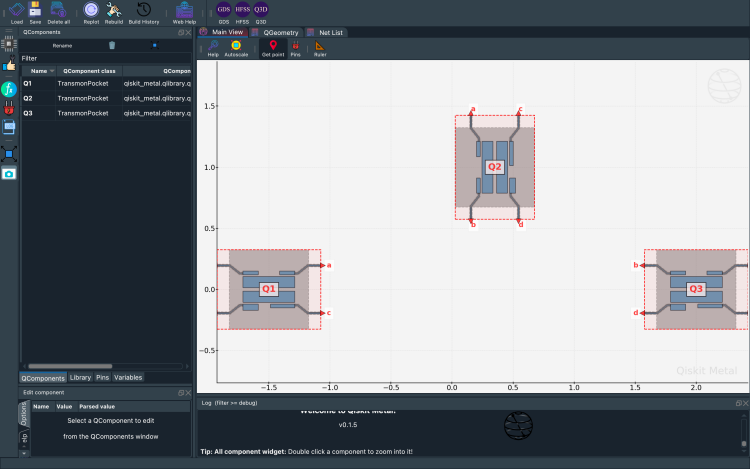

In [9]:
gui.screenshot()

In [10]:
# Using CPW meanders to connect the 3 qubits 
from qiskit_metal.qlibrary.tlines.meandered import RouteMeander 
RouteMeander.get_template_options(design)

{'chip': 'main',
 'layer': '1',
 'pin_inputs': {'start_pin': {'component': '', 'pin': ''},
  'end_pin': {'component': '', 'pin': ''}},
 'fillet': '0',
 'lead': {'start_straight': '0mm',
  'end_straight': '0mm',
  'start_jogged_extension': '',
  'end_jogged_extension': ''},
 'total_length': '7mm',
 'trace_width': 'cpw_width',
 'meander': {'spacing': '200um', 'asymmetry': '0um'},
 'snap': 'true',
 'prevent_short_edges': 'true',
 'hfss_wire_bonds': False,
 'q3d_wire_bonds': False,
 'aedt_q3d_wire_bonds': False,
 'aedt_hfss_wire_bonds': False}

Let's define a dictionary with the options we want to keep global. We will then concatenate this dictionary to the ones we will use to describe the individual qubits. 

In [18]:
ops = dict(fillet='90um')

Let's define the first CPW component 

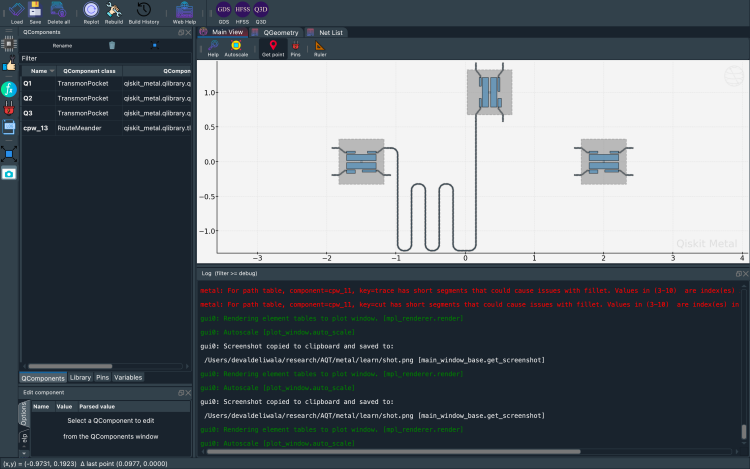

In [39]:
options = Dict(
    total_length= '8mm',
    hfss_wire_bonds = True,
    pin_inputs=Dict(
        start_pin=Dict(
            component= 'Q1',
            pin= 'a'),
        end_pin=Dict(
            component= 'Q2',
            pin= 'b')),
    lead=Dict(
        start_straight='0.1mm',
        end_straight='0.5mm'),
    meander=Dict(
       asymmetry='-1mm'),
    **ops
)

# Below I am creating a CPW without assigning its name.
#  Therefore running this cell twice will create two CPW's instead of overwriting the previous one
#  To prevent that we add the cpw.delete() statement.
#  The try-except wrapping is needed to suppress errors during the first run of this cell
try:
    cpw.delete()
except NameError: pass

cpw = RouteMeander(design, options=options)
gui.rebuild() 
gui.autoscale() 
gui.screenshot()

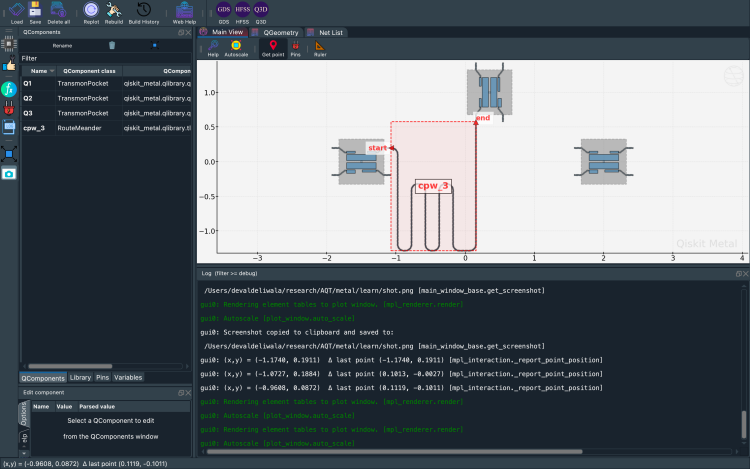

In [24]:
cpw.options.lead.start_straight = '100um' 
gui.rebuild() 
gui.autoscale() 
gui.highlight_components(['cpw_3'])
gui.screenshot()

In [25]:
%metal_print Practice

Let's create another 3 CPWs for practice

In [48]:
options = Dict(
    total_length='6mm', 
    pin_inputs=Dict(
        start_pin=Dict(
            component='Q2', 
            pin='d'), 
        end_pin=Dict(
            component='Q3', 
            pin='b')), 
    lead=Dict(
        start_straight='0.1mm', 
        end_straight='0.2mm'), 
    meander=Dict(
        asymmetry='-0.9mm'), 
    **ops 
)

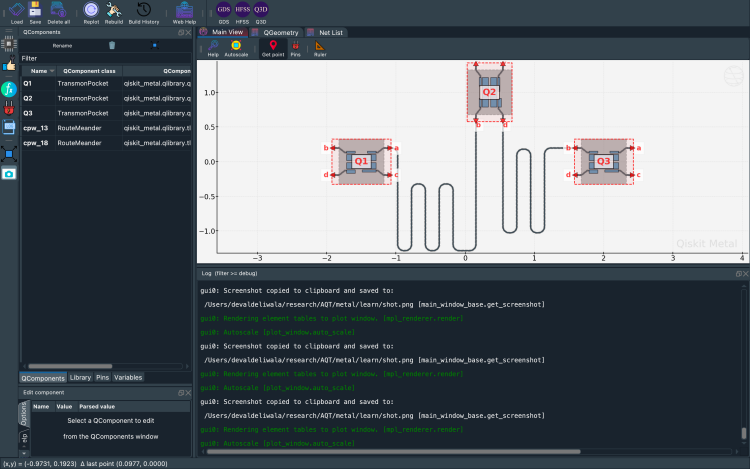

In [49]:
try: 
    cpw2.delete() 
except NameError: pass 

cpw2 = RouteMeander(design, options=options)
gui.rebuild()
gui.autoscale()
gui.highlight_components(['Q1', 'Q2', 'Q3'])
gui.screenshot()

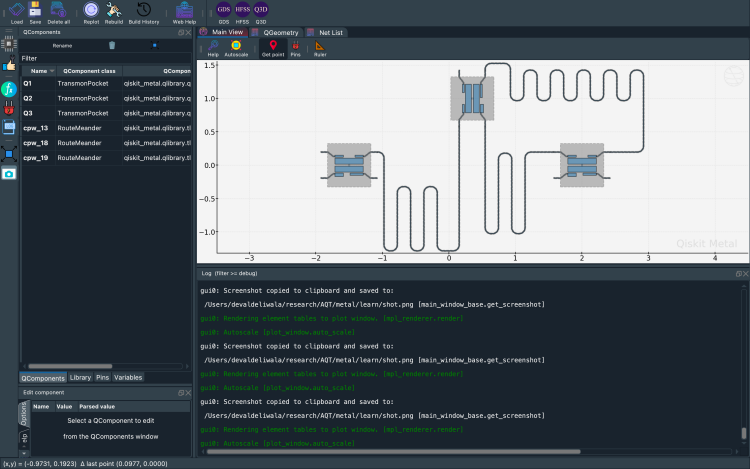

In [50]:
options = Dict(
    total_length= '8mm',
    pin_inputs=Dict(
        start_pin=Dict(
            component= 'Q3',
            pin= 'a'),
        end_pin=Dict(
            component= 'Q2',
            pin= 'c')),
    lead=Dict(
        start_straight='0.5mm',
        end_straight='0.1mm'),
    meander=Dict(
       asymmetry='-1mm'),
    **ops
)

try:
    cpw3.delete()
except NameError: pass

cpw3 = RouteMeander(design,options=options)
gui.rebuild()
gui.autoscale()
gui.screenshot()

In [51]:
options = Dict(
    total_length= '8mm',
    pin_inputs=Dict(
        start_pin=Dict(
            component= 'Q1',
            pin= 'b'),
        end_pin=Dict(
            component= 'Q2',
            pin= 'a')),
    lead=Dict(
        start_straight='0.5mm',
        end_straight='0.1mm'),
    meander=Dict(
       asymmetry='1mm'),
    **ops
)

try:
    cpw4.delete()
except NameError: pass

cpw4 = RouteMeander(design,options=options)
gui.rebuild()
gui.autoscale()

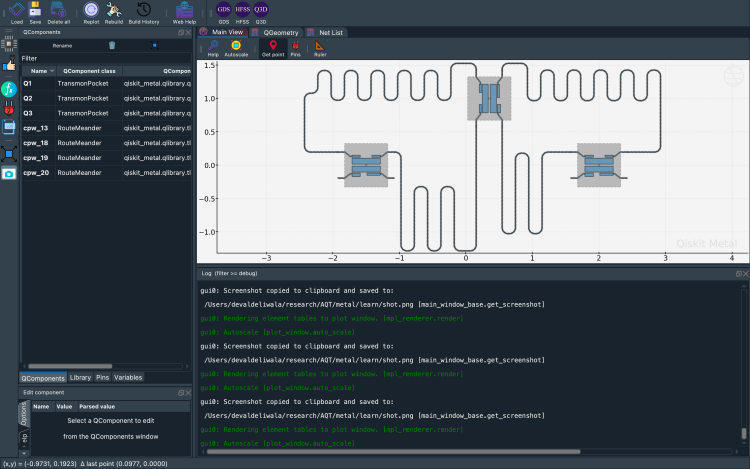

In [52]:
gui.screenshot()

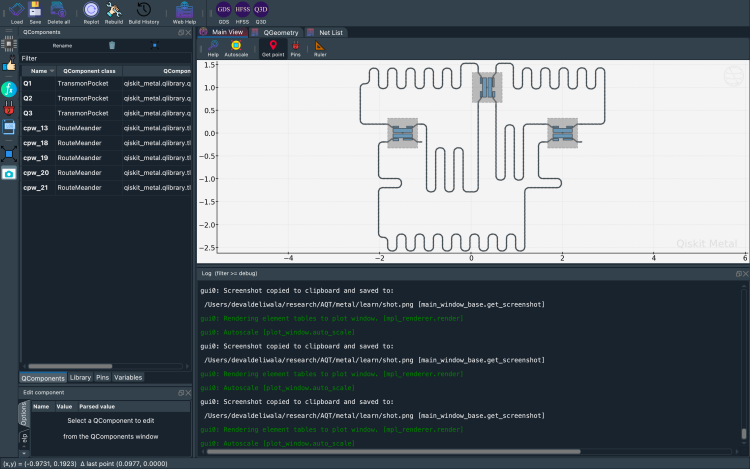

In [53]:
from collections import OrderedDict
jogs = OrderedDict()
jogs[0] = ["L", '800um']
jogs[1] = ["L", '500um']
jogs[2] = ["R", '200um']
jogs[3] = ["R", '500um']

options = Dict(
    total_length= '14mm',
    pin_inputs=Dict(
        start_pin=Dict(
            component= 'Q1',
            pin= 'd'),
        end_pin=Dict(
            component= 'Q3',
            pin= 'd')),
    lead=Dict(
        start_straight='0.1mm',
        end_straight='0.1mm',
        start_jogged_extension=jogs,
        end_jogged_extension=jogs),
    meander=Dict(
       asymmetry='-1.2mm'),
    **ops
)

try:
    cpw5.delete()
except NameError: pass

cpw5 = RouteMeander(design,options=options)
gui.rebuild()
gui.autoscale()
gui.screenshot()

In [54]:
q4 = TransmonPocket(design, 'Q4', options = dict(pos_x='-7.5mm', pos_y='-0.5mm', **optionsQ))
q5 = TransmonPocket(design, 'Q5', options = dict(pos_x='-5.65mm', pos_y='+0.5mm', orientation = '90',**optionsQ))
q6 = TransmonPocket(design, 'Q6', options = dict(pos_x='-4.0mm', pos_y='-0.6mm', **optionsQ))
gui.rebuild()

options = Dict(
    total_length= '3.4mm',
    pin_inputs=Dict(
        start_pin=Dict(
            component= 'Q4',
            pin= 'a'),
        end_pin=Dict(
            component= 'Q5',
            pin= 'b')),
    lead=Dict(
        start_straight='0.5mm',
        end_straight='0.1mm'),
    meander=Dict(
       asymmetry='1mm'),
    **ops
)
try:
    cpw6.delete()
except NameError: pass
cpw6 = RouteMeander(design, options=options)
gui.rebuild()
gui.autoscale() 

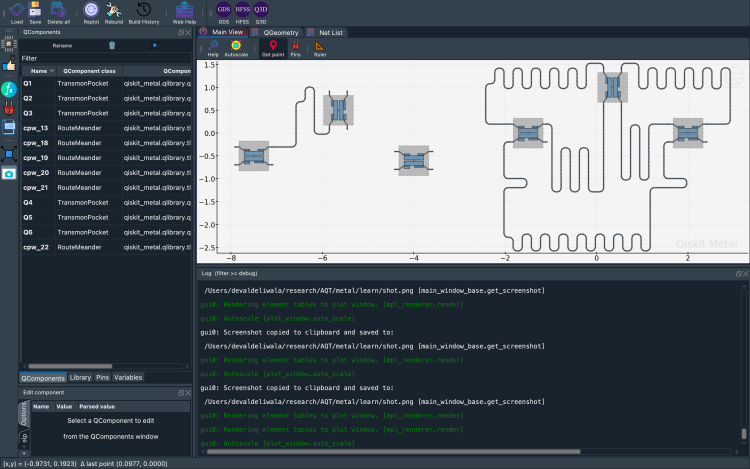

In [55]:
gui.screenshot()